# Squared Loss (Mean Squared Error)

This notebook demonstrates the calculation and properties of squared loss, one of the most fundamental loss functions in machine learning and statistics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ============================================================================
# Helper Functions for Squared Loss Calculation
# ============================================================================

def squared_loss(y_true, y_pred):
    """
    Calculate squared loss (also called Mean Squared Error).
    
    Parameters:
    -----------
    y_true : array-like or float
        True values (actual/target values)
    y_pred : array-like or float
        Predicted values
    
    Returns:
    --------
    float or ndarray
        Squared loss value(s). For multiple samples, returns loss for each sample.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return (y_true - y_pred) ** 2


def mean_squared_loss(y_true, y_pred):
    """
    Calculate mean squared error (MSE) across all samples.
    
    Parameters:
    -----------
    y_true : array-like
        True values
    y_pred : array-like
        Predicted values
    
    Returns:
    --------
    float
        Mean squared error value
    """
    losses = squared_loss(y_true, y_pred)
    return np.mean(losses)

## What is Squared Loss?

**Squared Loss** (also called **Mean Squared Error** or **MSE**) is a loss function that measures the average of the squared differences between predicted values and actual values.

### Mathematical Definition

For a single prediction:
$$L(y_{true}, y_{pred}) = (y_{true} - y_{pred})^2$$

For multiple predictions (Mean Squared Error):
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i^{true} - y_i^{pred})^2$$

### Key Properties

1. **Non-negative**: Loss is always ≥ 0
2. **Convex**: Has a single global minimum (good for optimization)
3. **Smooth**: Differentiable everywhere (enables gradient descent)
4. **Penalizes larger errors more**: Quadratic penalty encourages accurate predictions

### Why Use Squared Loss?

- Differentiable: Can compute gradients for optimization
- Convex: Guaranteed to find global optimum
- Interpretable: Units are squared prediction units
- Mathematically elegant: Related to Gaussian distributions
- Standard choice for regression problems

## Example 1: Single Prediction

In [2]:
# Calculate squared loss for a single prediction
y_true = 5.0
y_pred = 3.0

loss = squared_loss(y_true, y_pred)

print("="*70)
print("Example 1: Single Prediction Squared Loss")
print("="*70)
print()
print(f"True value:       y_true = {y_true}")
print(f"Predicted value:  y_pred = {y_pred}")
print()
print(f"Error (residual): y_true - y_pred = {y_true - y_pred}")
print(f"Squared Loss:     (y_true - y_pred)² = {loss}")
print()
print(f"Interpretation: The model's prediction was off by {abs(y_true - y_pred):.1f} units,")
print(f"resulting in a loss of {loss:.1f}")

Example 1: Single Prediction Squared Loss

True value:       y_true = 5.0
Predicted value:  y_pred = 3.0

Error (residual): y_true - y_pred = 2.0
Squared Loss:     (y_true - y_pred)² = 4.0

Interpretation: The model's prediction was off by 2.0 units,
resulting in a loss of 4.0


## Example 2: Multiple Predictions (Mean Squared Error)

In [3]:
# Calculate MSE for multiple predictions
y_true = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = np.array([1.1, 1.9, 3.2, 3.8, 5.3])

# Calculate squared errors for each prediction
squared_errors = squared_loss(y_true, y_pred)

# Calculate mean squared error
mse = mean_squared_loss(y_true, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error

print()
print("="*70)
print("Example 2: Mean Squared Error (Multiple Predictions)")
print("="*70)
print()
print("Data:")
print(f"  y_true = {y_true}")
print(f"  y_pred = {y_pred}")
print()
print("Squared Errors:")
for i, (yt, yp, se) in enumerate(zip(y_true, y_pred, squared_errors)):
    print(f"  Sample {i+1}: ({yt:.1f} - {yp:.1f})² = {se:.4f}")
print()
print(f"Mean Squared Error (MSE):     {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print()
print(f"Interpretation: On average, predictions are off by {rmse:.4f} units")


Example 2: Mean Squared Error (Multiple Predictions)

Data:
  y_true = [1. 2. 3. 4. 5.]
  y_pred = [1.1 1.9 3.2 3.8 5.3]

Squared Errors:
  Sample 1: (1.0 - 1.1)² = 0.0100
  Sample 2: (2.0 - 1.9)² = 0.0100
  Sample 3: (3.0 - 3.2)² = 0.0400
  Sample 4: (4.0 - 3.8)² = 0.0400
  Sample 5: (5.0 - 5.3)² = 0.0900

Mean Squared Error (MSE):     0.038000
Root Mean Squared Error (RMSE): 0.194936

Interpretation: On average, predictions are off by 0.1949 units


## Example 3: Visualizing Squared Loss

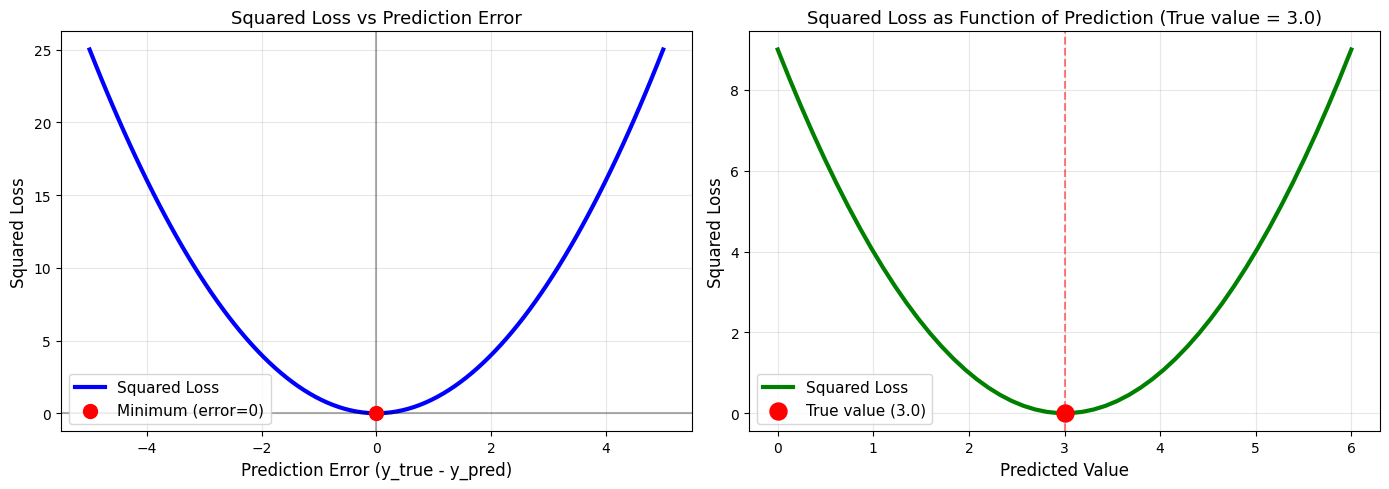


Key observations from visualization:
1. Loss is minimum (0) when error = 0 (perfect prediction)
2. Loss increases quadratically as error increases
3. Loss is symmetric: error of +2 or -2 gives same loss
4. Larger errors are penalized more (quadratic growth)


In [4]:
# Visualize squared loss as a function of prediction error
error = np.linspace(-5, 5, 100)
loss = error**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss vs Error
ax1 = axes[0]
ax1.plot(error, loss, 'b-', linewidth=3, label='Squared Loss')
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax1.scatter([0], [0], color='red', s=100, zorder=5, label='Minimum (error=0)')
ax1.set_xlabel('Prediction Error (y_true - y_pred)', fontsize=12)
ax1.set_ylabel('Squared Loss', fontsize=12)
ax1.set_title('Squared Loss vs Prediction Error', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Plot 2: Multiple data points with their losses
ax2 = axes[1]
y_true_pt = 3.0
y_pred_range = np.linspace(0, 6, 50)
loss_range = (y_true_pt - y_pred_range)**2

ax2.plot(y_pred_range, loss_range, 'g-', linewidth=3, label='Squared Loss')
ax2.scatter([y_true_pt], [0], color='red', s=150, zorder=5, label=f'True value ({y_true_pt})')
ax2.axvline(x=y_true_pt, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Predicted Value', fontsize=12)
ax2.set_ylabel('Squared Loss', fontsize=12)
ax2.set_title(f'Squared Loss as Function of Prediction (True value = {y_true_pt})', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print()
print("Key observations from visualization:")
print("1. Loss is minimum (0) when error = 0 (perfect prediction)")
print("2. Loss increases quadratically as error increases")
print("3. Loss is symmetric: error of +2 or -2 gives same loss")
print("4. Larger errors are penalized more (quadratic growth)")

## Example 4: Gradient of Squared Loss


Example 4: Gradient of Squared Loss

Loss function: L = (y_true - y_pred)²

∂L/∂y_pred = 2*y_pred - 2*y_true
∂L/∂y_true = -2*y_pred + 2*y_true

Interpretation:
- Gradient is proportional to the error (y_true - y_pred)
- Factor of 2 appears due to the chain rule
- Gradient points in direction of decreasing loss

At y_true = 5.0, y_pred = 3.0:
  Error: 2.0
  ∂L/∂y_pred = -4.0

Interpretation: To decrease loss, increase y_pred by 
moving in negative gradient direction: 3.0 - learning_rate * -4.0



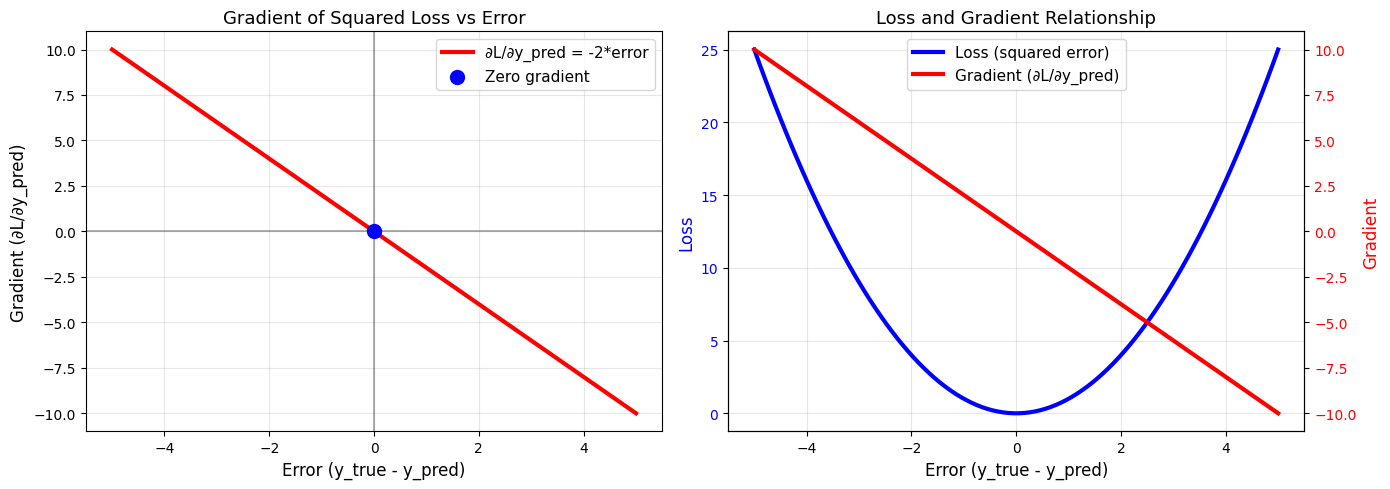


Key observations from gradient visualization:
1. Gradient is zero when error = 0 (at minimum)
2. Gradient is linear with respect to error
3. Negative error → positive gradient (increase y_pred)
4. Positive error → negative gradient (decrease y_pred)
5. Larger errors produce larger gradients (steeper updates)


In [5]:
# Compute gradient of squared loss using symbolic math
y_true_sym = sp.Symbol('y_true', real=True)
y_pred_sym = sp.Symbol('y_pred', real=True)

# Define squared loss function
loss_sym = (y_true_sym - y_pred_sym)**2

# Compute partial derivatives
d_loss_d_ypred = sp.diff(loss_sym, y_pred_sym)
d_loss_d_ytrue = sp.diff(loss_sym, y_true_sym)

print()
print("="*70)
print("Example 4: Gradient of Squared Loss")
print("="*70)
print()
print(f"Loss function: L = (y_true - y_pred)²")
print()
print(f"∂L/∂y_pred = {d_loss_d_ypred}")
print(f"∂L/∂y_true = {d_loss_d_ytrue}")
print()
print("Interpretation:")
print("- Gradient is proportional to the error (y_true - y_pred)")
print("- Factor of 2 appears due to the chain rule")
print("- Gradient points in direction of decreasing loss")
print()

# Numerical example
y_true_val = 5.0
y_pred_val = 3.0

gradient = float(d_loss_d_ypred.subs([(y_true_sym, y_true_val), (y_pred_sym, y_pred_val)]))

print(f"At y_true = {y_true_val}, y_pred = {y_pred_val}:")
print(f"  Error: {y_true_val - y_pred_val}")
print(f"  ∂L/∂y_pred = {gradient}")
print()
print(f"Interpretation: To decrease loss, increase y_pred by ",)
print(f"moving in negative gradient direction: {y_pred_val} - learning_rate * {gradient}")
print()

# Visualize gradient as function of error
error = np.linspace(-5, 5, 100)
gradient_vals = -2 * error  # ∂L/∂y_pred = -2(y_true - y_pred) = -2*error

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gradient vs Error
ax1 = axes[0]
ax1.plot(error, gradient_vals, 'r-', linewidth=3, label='∂L/∂y_pred = -2*error')
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax1.scatter([0], [0], color='blue', s=100, zorder=5, label='Zero gradient')
ax1.set_xlabel('Error (y_true - y_pred)', fontsize=12)
ax1.set_ylabel('Gradient (∂L/∂y_pred)', fontsize=12)
ax1.set_title('Gradient of Squared Loss vs Error', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Plot 2: Loss and Gradient together
ax2 = axes[1]
loss = error**2
ax2_twin = ax2.twinx()

# Plot loss on left y-axis
line1 = ax2.plot(error, loss, 'b-', linewidth=3, label='Loss (squared error)')
ax2.set_ylabel('Loss', fontsize=12, color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Plot gradient on right y-axis
line2 = ax2_twin.plot(error, gradient_vals, 'r-', linewidth=3, label='Gradient (∂L/∂y_pred)')
ax2_twin.set_ylabel('Gradient', fontsize=12, color='r')
ax2_twin.tick_params(axis='y', labelcolor='r')

ax2.set_xlabel('Error (y_true - y_pred)', fontsize=12)
ax2.set_title('Loss and Gradient Relationship', fontsize=13)
ax2.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper center', fontsize=11)

plt.tight_layout()
plt.show()

print()
print("Key observations from gradient visualization:")
print("1. Gradient is zero when error = 0 (at minimum)")
print("2. Gradient is linear with respect to error")
print("3. Negative error → positive gradient (increase y_pred)")
print("4. Positive error → negative gradient (decrease y_pred)")
print("5. Larger errors produce larger gradients (steeper updates)")

## Summary: Squared Loss

### Definition
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i^{true} - y_i^{pred})^2$$

### Key Characteristics

| Property | Description |
|----------|-------------|
| **Range** | [0, ∞) |
| **Optimal value** | 0 (perfect predictions) |
| **Differentiability** | Differentiable everywhere |
| **Convexity** | Strictly convex |
| **Gradient** | ∂L/∂y_pred = -2(y_true - y_pred) |
| **Penalty growth** | Quadratic (large errors heavily penalized) |
| **Outlier sensitivity** | High (sensitive to outliers) |

### Gradient

$$\frac{\partial L}{\partial y_{pred}} = -2(y_{true} - y_{pred})$$

This gradient is crucial for optimization:
- Points in direction of steepest descent
- Proportional to the error
- Enables gradient descent updates

### When to Use

**Best for:**
- Regression problems
- Normally distributed errors
- When outliers are not a major concern
- When you need smooth optimization

**Consider alternatives when:**
- Data has significant outliers (use L1 or Huber loss)
- Error distribution is non-normal
- You need interpretability in original units (use RMSE, MAE)

### Related Concepts

- **RMSE** (Root Mean Squared Error): √MSE - in same units as target
- **SSE** (Sum of Squared Errors): n × MSE - total squared error
- **R²** (Coefficient of Determination): 1 - (SSE/SST) - explained variance
- **MAE** (Mean Absolute Error): Alternative loss for robustness